# <center>Convolutional Neural Networks</center>
## <center>Inclass Project 4 - MA4144</center>

This project contains 5 tasks/questions to be completed, some require written answers. Questions that required written answers are given in blue fonts. Almost all written questions are open ended, they do not have a correct or wrong answer. You are free to give your opinions, but please provide related answers within the context.

After finishing project run the entire notebook once and **save the notebook as a pdf** (File menu -> Save and Export Notebook As -> PDF). You are **required to upload both the PDF and the ipynb file on moodle**.

***

## Outline of the project

The aim of the project is to practically learn and implement about CNN. This project will have two main sections.

Section 1: Build a convolutional layer and pooling layer from scratch. Then test them on a sample image.

Section 2: Use the Keras library to implement a CNN to classify images on the [CIFAR10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html).

***


Use the below cell to use any include any imports

In [1]:
import time
start_time = time.time()
import numpy as np
import matplotlib.pyplot as plt
import random
from keras.preprocessing.image import load_img
import keras
from scipy import signal

## Section 1: Convolution and Pooling

**Q1** In the following cell, implement a method called create_padding. The method will take in input_image ($n \times m$) and will return a zero-padded image called output_image of dimension $(n + 2d) \times (m + 2d)$ where $d$ is the padding thickness on either side.

In [2]:
def create_padding(input_image, d):

    #TODO

    n, m = input_image.shape
    # Preallocate output once, then place input into the correct slice
    output_image = np.zeros((n + 2 * d, m + 2 * d), dtype=input_image.dtype)
    output_image[d:d + n, d:d + m] = input_image

    return output_image


In [3]:
input_image = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
padded_image = create_padding(input_image, 1)
print(padded_image)

[[0 0 0 0 0]
 [0 1 2 3 0]
 [0 4 5 6 0]
 [0 7 8 9 0]
 [0 0 0 0 0]]


**Q2** In the following cell, implement a method called convolution. The method will take in input_image ($n \times m$), kernel ($k \times k$) and will return output_image of dimension $(n - k + 1) \times (m - k + 1)$. The output_image is the result of the convolution between input_image and kernel. You may assume that the stride is $1$.

In [4]:

def convolution(input_image, kernel):
    rows, cols = input_image.shape
    f_size, _ = kernel.shape

    out_rows = rows - f_size + 1
    out_cols = cols - f_size + 1

    output_image = np.zeros((out_rows, out_cols), dtype=np.float64)

    r = 0
    while r < out_rows:
        c = 0
        while c < out_cols:
            patch = input_image[r:r + f_size, c:c + f_size]
            output_image[r, c] = np.sum(patch * kernel)
            c += 1
        r += 1

    return output_image


**Q3** In the following cell, implement a method called pooling. The method will take in input_image ($n \times m$), $p$ the pooling dimension, pooling_type (either max_pooling or avg_pooling) and will return output_image of dimension $(n - p + 1) \times (m - p + 1)$. The output_image is the result of performing pooling on input_image by a window of dimension $p \times p$. You may assume that the stride is $1$.

In [5]:
def pooling(input_image, p, pooling_type = "max_pooling"):

    n, m = input_image.shape
    out_n = n - p + 1
    out_m = m - p + 1
    output_image = np.zeros((out_n, out_m))

    if pooling_type == "max_pooling":

        #TODO
        for i in range(out_n):
            for j in range(out_m):
                output_image[i, j] = np.max(input_image[i:i+p, j:j+p])

    elif pooling_type == "avg_pooling":

        #TODO
        for i in range(out_n):
            for j in range(out_m):
                output_image[i, j] = np.mean(input_image[i:i+p, j:j+p])

    else:
        print("Error: Invalid pooling type")
        return

    return(output_image)


In [6]:
input_image = np.array([[1, 2, 3],
                        [4, 5, 6],
                        [7, 8, 9]])

print("Max pooling:\n", pooling(input_image, 2, "max_pooling"))
print("Avg pooling:\n", pooling(input_image, 2, "avg_pooling"))

Max pooling:
 [[5. 6.]
 [8. 9.]]
Avg pooling:
 [[3. 4.]
 [6. 7.]]


The 'lena' image is widely used for image processing experiments and has been a benchmark image until recently.
We will use a $512 \times 512$ grayscale lena sample to test our convolution and pooling implementations.

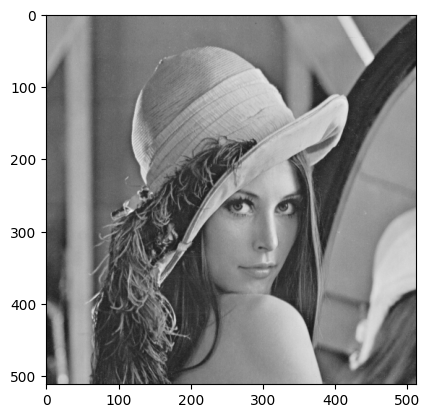

In [7]:
lena = load_img('lena.gif')
plt.imshow(lena)
plt.show()

**Q4** In the following perform convolution on lena. Make sure you use padding appropriately to maintain the image size after convolution. However, pooling should be done on an unpadded image and image size may not be preseved after pooling. Use the following kernels to perform convolution and pooling separately.

1. $\begin{bmatrix} +1 & 0 & -1 \\ +1 & 0 & -1 \\ +1 & 0 & -1 \end{bmatrix}$
   
2. $\begin{bmatrix} -1 & -1 & -1 \\ 0 & 0 & 0 \\ +1 & +1 & +1 \end{bmatrix}$

3. $\begin{bmatrix} -1 & 0 & +1 \\ -2 & 0 & +2 \\ -1 & 0 & +1 \end{bmatrix}$

4. $\begin{bmatrix} +1 & +2 & +1 \\ 0 & 0 & 0 \\ -1 & -2 & -1 \end{bmatrix}$

5. Any other kernel that you may find interesting.

The following outputs are expected:
1. lena kernel 1 convolution and then max pooled, set your output to the variable lena_kernel_1_maxpool.
2. lena kernel 2 convolution and then average pooled, set your output to the variable lena_kernel_2_avgpool.
3. lena kernel 3 convolution and then max pooled, set your output to the variable lena_kernel_3_maxpool.
4. lena kernel 4 convolution and then average pooled, set your output to the variable lena_kernel_4_avgpool.

In [8]:
#Write code to use your convolution and pooling methods.
# Define kernels
kernels = [
    np.array([[+1, 0, -1], [+1, 0, -1], [+1, 0, -1]]),  # Kernel 1
    np.array([[-1, -1, -1], [0, 0, 0], [+1, +1, +1]]),  # Kernel 2
    np.array([[-1, 0, +1], [-2, 0, +2], [-1, 0, +1]]),  # Kernel 3
    np.array([[+1, +2, +1], [0, 0, 0], [-1, -2, -1]]),
    np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
]

#  Perform padded convolution then pooling
def apply_kernel_and_pool(image, kernel, pool_type="max_pooling"):
    padded = create_padding(image, kernel.shape[0] // 2)
    convolved = convolution(padded, kernel)
    pooled = pooling(convolved, 2, pooling_type=pool_type)
    return convolved, pooled

# Load the image and convert it to grayscale
lena = np.array(load_img('lena.gif').convert('L'))  # Convert to grayscale

results = []
results.append(apply_kernel_and_pool(lena, kernels[0], "max_pooling"))
results.append(apply_kernel_and_pool(lena, kernels[1], "avg_pooling"))
results.append(apply_kernel_and_pool(lena, kernels[2], "max_pooling"))
results.append(apply_kernel_and_pool(lena, kernels[3], "avg_pooling"))
results.append(apply_kernel_and_pool(lena, kernels[4], "max_pooling"))

# Assign outputs
lena_kernel_1_maxpool = results[0][1]
lena_kernel_2_avgpool = results[1][1]
lena_kernel_3_maxpool = results[2][1]
lena_kernel_4_avgpool = results[3][1]

<font color='blue'>Explain what each of the above kernels (including your choice) will do to the image.</font>

In [9]:
#Write your answers as a string (max 2 sentences per kernel)

Ans_Kernel_1 = "This kernel is designed to detect vertical edges in an image. It applies a strong response in areas where there are sudden changes in pixel values along the horizontal direction, highlighting structures and features that are vertically oriented"
Ans_Kernel_2 = "This kernel detects horizontal edges by capturing the transitions along the vertical axis, which makes it useful for identifying edges that run horizontally across the image like horizon,rows or other similar horizontal features."
Ans_Kernel_3 = "This kernel detects diagonal edges . it captures the edges running from top left to botoon right conner and this is helpful to identify the diagonal patterns lie within the image."
Ans_Kernel_4 = "This kernel detects diagonal edges in other direction (top right to bottom left), Thiscan be useful for detecting diagonal elements that Kernel 3 may miss, ensuring edge detection in both diagonal directions"
Ans_Kernel_5 = "This filter also knows as sharpning filter enhances edges and details in an image by increasing contrast between neighboring pixels"

Show the resulting image after convolution and pooling separately on two subplots (of the same plot) for each kernel. There should be 5 plots with two sub plots in each.

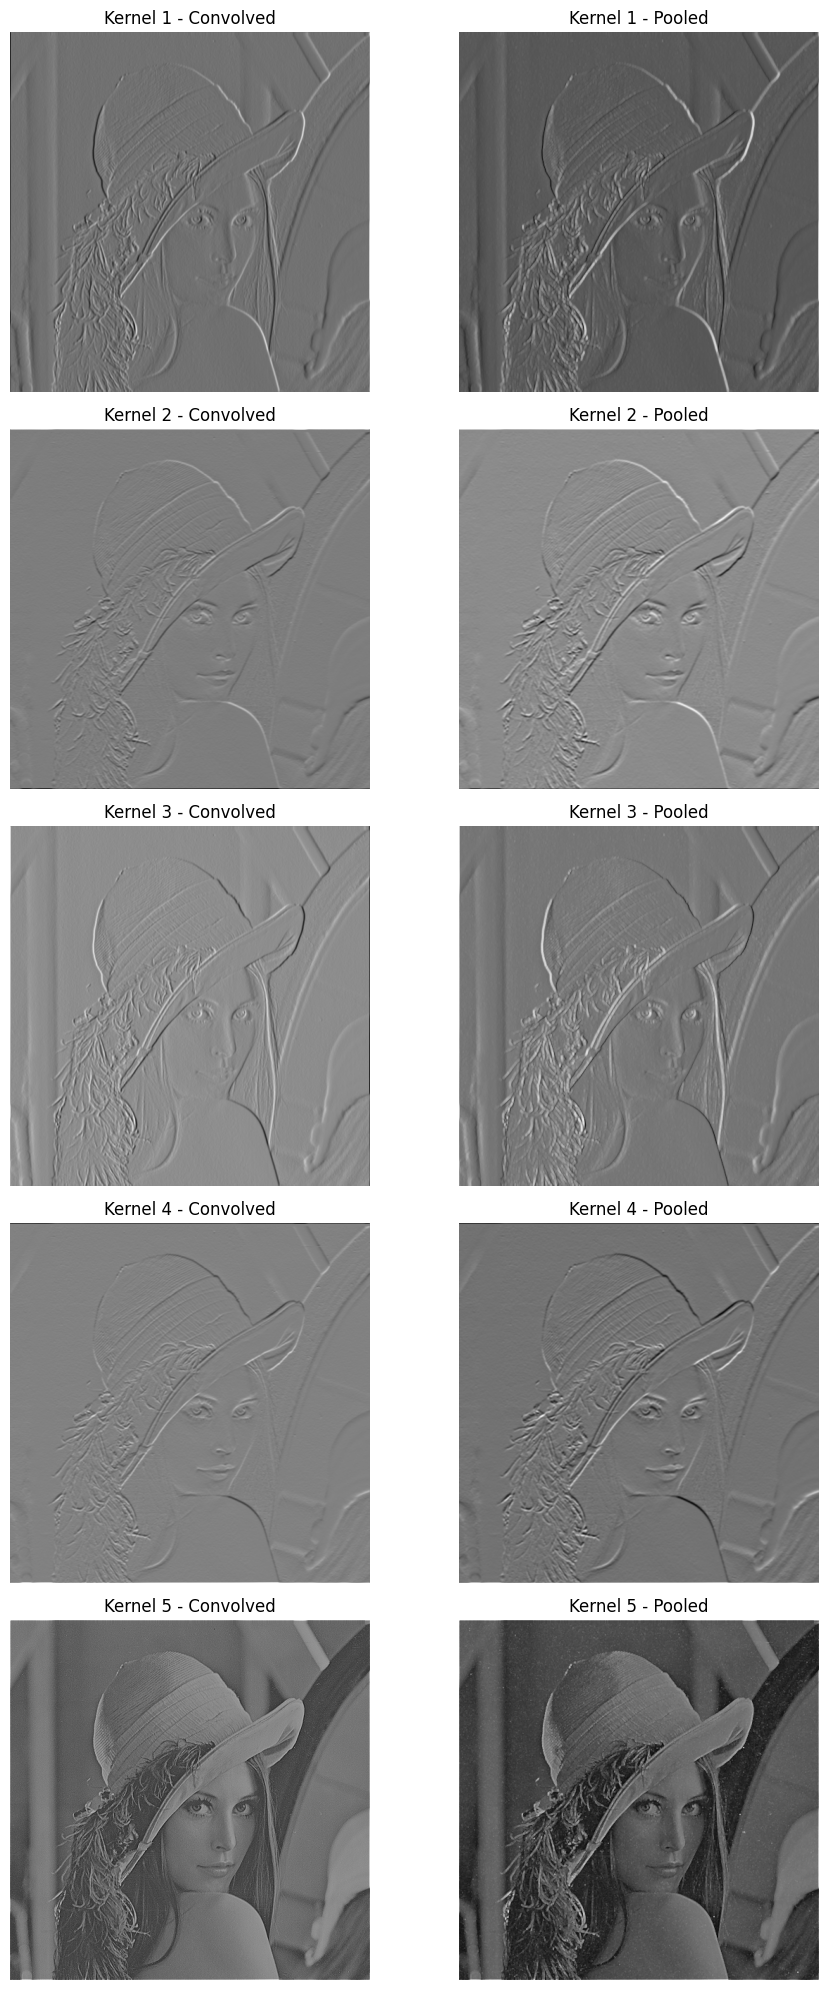

In [10]:
fig, axes = plt.subplots(5, 2, figsize=(10, 20))
titles = ["Kernel 1", "Kernel 2", "Kernel 3", "Kernel 4", "Kernel 5"]
for i in range(5):
    convolved, pooled = results[i]
    axes[i, 0].imshow(convolved, cmap='gray')
    axes[i, 0].set_title(f'{titles[i]} - Convolved')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(pooled, cmap='gray')
    axes[i, 1].set_title(f'{titles[i]} - Pooled')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## Section 2: Using Keras to implement CNN for image classification

This section, unlike the previous projects you are granted full liberty to **build the structure of your model appropriately using keras**. I have provided only the code to download the cifar10 dataset. (Note that cifar10 contains rgb images with 3 channels unlike the grayscake image lena we used earlier.)

**Final expected outcome:** For the best CNN model architecture and parameters you find, **your model is required to be able to provide accurate predictions**. The **accuracy rate will determine your score**. Make sure you **normalize the input training/testing images to $[0, 1]$** before training. For this **implement a predict function** - instructions given below.

Hint: To improve your model you may use the following techniques.
1. 5-fold cross validation accuracy.
2. Testing accuracy.
3. Confusion matrix of the result.
4. Precision recall for each class.

Test on different hyperparameters and network architectures and select decide the best performer based on the cross-validation accuracy.

In [11]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [12]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import random
import time

random.seed(32)
np.random.seed(32)
tf.random.set_seed(32)

class TimeLimit(tf.keras.callbacks.Callback):
    def __init__(self, max_seconds: float, t0: float | None = None):
        super().__init__()
        self.max_seconds = max_seconds
        self._external_t0 = t0
        self._t0 = None
        self.epochs_completed = 0

    def on_train_begin(self, logs=None):
        # If an external start time was provided (earlier cell), use it.
        # Otherwise, start the clock now.
        self._t0 = self._external_t0 if self._external_t0 is not None else time.time()

    def on_epoch_end(self, epoch, logs=None):
        # Track the number of epochs
        self.epochs_completed += 1

        if time.time() - self._t0 >= self.max_seconds:
            self.model.stop_training = True

    def on_train_batch_end(self, batch, logs=None):
        if time.time() - self._t0 >= self.max_seconds:
            self.model.stop_training = True

# Classes for output mapping
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Load CIFAR-10, use only a small subset for training
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()


def create_fast_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = create_fast_model()
history = model.fit(
    x_train, y_train,
    epochs=23,
    batch_size=256,
    verbose=0,
    callbacks=[TimeLimit(200.0, t0=start_time)]
)


In [13]:
#In this cell define the function predict, which will predict the class of test_images using your best CNN-model.
#The output should be a python list of strings of classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)
#Your work will be mainly evaluated based on this.
#The grader will test it against input images and your score will be determined based on the number of correct predictions.
#Expect the input to be a torch tensor of shape [64, 3, 32, 32] with normalized values [0, 1]

def predict(test_images, batch_size=256):
    np_images = test_images.numpy()  # shape: (N, 3, 32, 32)
    np_images = np.transpose(np_images, (0, 2, 3, 1))  # shape: (N, 32, 32, 3)

    # Normalize if needed
    if np_images.max() > 1.0:
        np_images = np_images.astype("float32") / 255.0

    # Predict using Keras model
    preds = model.predict(np_images, batch_size=batch_size, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    predictions = [class_names[i] for i in pred_labels]
    return predictions

In [14]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.6001
